**Study:** *The Carbon Cost of Everyday Python: A Reproducible Study of Energy-Efficient Data Processing Practices*

This notebook implements the complete analysis for the benchmark experiment:

- 8 processing implementations
- 2 file formats: CSV / Parquet
- 2 numeric data types: Float32 / Float64
- 2 categorical representations: object / category
- 2 execution modes: single / parallel
- 10 randomized blocks
- 128 configurations × 10 repetitions = **1,280 measured runs**

## Statistical strategy

1. Validate the experimental design and measurement quality.
2. Compute descriptive statistics and 95% confidence intervals.
3. Rank all 128 configurations by mean energy.
4. Visualize implementation, factor, interaction, and block effects.
5. Fit the **original-scale five-factor Type III factorial model with block**.
6. Test residual normality using **Shapiro–Wilk** and inspect a Q–Q plot.
7. Test homogeneity using **Levene / Brown–Forsythe**.
8. Because assumptions are violated, use **exact ART ANOVA** as the primary inferential analysis.
9. Use **ART-C** for selected post-hoc/simple-effect contrasts and **Holm correction**.
10. Estimate **partial eta-squared from the original-scale factorial model**.
11. Analyze runtime, memory, average power, energy-delay product, and Pareto trade-offs.
12. Check block/order drift and leave-one-block-out robustness.

> **Important:** Energy is the primary outcome. Runtime and peak memory are secondary outcomes.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports and reproducibility settings

In [ ]:
from pathlib import Path
import os, sys, math, json, shutil, subprocess, textwrap, warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

RANDOM_SEED = 407
np.random.seed(RANDOM_SEED)

if Path("/content").exists():
    BASE_DIR = Path("/content")
elif Path("/mnt/data").exists():
    BASE_DIR = Path("/mnt/data")
else:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "cse407_analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/cse407_analysis_outputs


## 1. Load the benchmark CSV

The notebook first looks for `/content/benchmark_test(4).csv`.  
If it is not present in Colab, it asks you to upload the CSV.

In [ ]:
DEFAULT_COLAB_PATH = Path("/content/drive/MyDrive/CSE407/benchmark_test.csv")
LOCAL_FALLBACK = Path("/mnt/data/benchmark_test(4).csv")

if DEFAULT_COLAB_PATH.exists():
    DATA_PATH = DEFAULT_COLAB_PATH
elif LOCAL_FALLBACK.exists():
    DATA_PATH = LOCAL_FALLBACK
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file was uploaded.")
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except ImportError:
        raise FileNotFoundError(
            "CSV not found. Set DATA_PATH manually to the benchmark CSV."
        )

df_raw = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())

Loaded: /content/drive/MyDrive/CSE407/benchmark_test.csv
Shape: (1280, 18)


,block,position_in_block,engine,data_format,numeric_dtype,categorical_dtype,threading_mode,config_id,runtime_s,energy_j,peak_rss_mb,rows_in,rows_out,result_hash,workers,status,error,timestamp
0,1,1,duckdb,csv,float64,object,parallel,duckdb__csv__float64__object__parallel,1.474371,20.947274,755.445312,500000,31,efb134c63bf1121267a2c40de5b87aa4b2539ab8e2eaca...,4,ok,NaN,2026-07-17 19:53:54 +0600
1,1,2,polars_eager,parquet,float32,object,parallel,polars_eager__parquet__float32__object__parallel,0.825949,9.635473,814.785156,500000,31,62e04c4fa2e12f64841233421786fadb607426af139979...,4,ok,NaN,2026-07-17 19:54:01 +0600
2,1,3,dask_default,csv,float64,object,parallel,dask_default__csv__float64__object__parallel,7.257616,112.549943,714.867188,500000,31,efb134c63bf1121267a2c40de5b87aa4b2539ab8e2eaca...,4,ok,NaN,2026-07-17 19:54:13 +0600
3,1,4,polars_lazy,csv,float32,object,single,polars_lazy__csv__float32__object__single,2.478595,31.550701,874.343750,500000,31,62e04c4fa2e12f64841233421786fadb607426af139979...,1,ok,NaN,2026-07-17 19:54:21 +0600
4,1,5,dask_default,parquet,float64,category,single,dask_default__parquet__float64__category__single,34.913989,477.368895,677.328125,500000,31,efb134c63bf1121267a2c40de5b87aa4b2539ab8e2eaca...,1,ok,NaN,2026-07-17 19:55:02 +0600


## 2. Clean names and validate the experimental design

`threading_mode` is renamed to **execution_mode**, because the parallel mechanism differs among implementations (threads, processes, or scheduler/workers).

The validation checks that:

- all expected columns exist;
- all measured rows succeeded;
- energy/runtime/memory values are positive;
- there are exactly 128 unique configurations;
- there are exactly 10 blocks;
- every configuration occurs exactly once in every block;
- every configuration has exactly 10 measured repetitions.

In [ ]:
df = df_raw.copy()

if "threading_mode" in df.columns and "execution_mode" not in df.columns:
    df = df.rename(columns={"threading_mode": "execution_mode"})

required_cols = [
    "block", "position_in_block", "engine", "data_format",
    "numeric_dtype", "categorical_dtype", "execution_mode",
    "config_id", "runtime_s", "energy_j", "peak_rss_mb",
    "rows_in", "rows_out", "result_hash", "workers", "status"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep successful measured runs.
failed = df.loc[df["status"].ne("ok")].copy()
if len(failed):
    print(f"WARNING: {len(failed)} failed rows will be excluded.")
    display(failed[["config_id", "block", "status", "error"]].head(20))

df = df.loc[df["status"].eq("ok")].copy()

# Basic validity
numeric_outcomes = ["energy_j", "runtime_s", "peak_rss_mb"]
if df[numeric_outcomes].isna().any().any():
    raise ValueError("Missing values found in the primary/secondary outcomes.")

if not (df[numeric_outcomes] > 0).all().all():
    raise ValueError("Zero or negative energy/runtime/memory measurements found.")

# Design checks
n_rows = len(df)
n_configs = df["config_id"].nunique()
n_blocks = df["block"].nunique()

print(f"Successful measured runs : {n_rows}")
print(f"Unique configurations    : {n_configs}")
print(f"Randomized blocks        : {n_blocks}")

expected_configs = 8 * 2 * 2 * 2 * 2
expected_blocks = 10
expected_rows = expected_configs * expected_blocks

assert n_configs == expected_configs, f"Expected {expected_configs} configurations, found {n_configs}"
assert n_blocks == expected_blocks, f"Expected {expected_blocks} blocks, found {n_blocks}"
assert n_rows == expected_rows, f"Expected {expected_rows} measurements, found {n_rows}"

# Exactly one observation per configuration per block
block_config_counts = df.groupby(["block", "config_id"], observed=True).size()
assert block_config_counts.eq(1).all(), "Some block × configuration cells are missing or duplicated."

# Exactly 10 observations per configuration
config_counts = df.groupby("config_id", observed=True).size()
assert config_counts.eq(expected_blocks).all(), "Not every configuration has exactly 10 repetitions."

print("\nDESIGN VALIDATION: PASSED")

Successful measured runs : 1280
Unique configurations    : 128
Randomized blocks        : 10

DESIGN VALIDATION: PASSED


## 3. Confirm factor levels and execution-mode implementation

In [ ]:
expected_levels = {
    "engine": [
        "pandas_numpy", "pandas_pyarrow", "polars_eager", "polars_lazy",
        "duckdb", "dask_default", "dask_pyarrow", "python_loops"
    ],
    "data_format": ["csv", "parquet"],
    "numeric_dtype": ["float32", "float64"],
    "categorical_dtype": ["object", "category"],
    "execution_mode": ["single", "parallel"],
}

for col, expected in expected_levels.items():
    observed = sorted(df[col].astype(str).unique())
    missing_levels = sorted(set(expected) - set(observed))
    extra_levels = sorted(set(observed) - set(expected))
    print(f"{col}: {observed}")
    if missing_levels or extra_levels:
        print("  WARNING:", {"missing": missing_levels, "extra": extra_levels})

# Use explicit category order for reproducible models/plots.
for col, levels in expected_levels.items():
    df[col] = pd.Categorical(df[col], categories=levels, ordered=False)

df["block"] = df["block"].astype("category")

print("\nWorkers by execution mode:")
display(pd.crosstab(df["execution_mode"], df["workers"]))

worker_check = (
    df.loc[df["execution_mode"].astype(str).eq("single"), "workers"].eq(1).all()
    and df.loc[df["execution_mode"].astype(str).eq("parallel"), "workers"].gt(1).all()
)
print("Execution-mode worker check:", "PASSED" if worker_check else "WARNING — inspect worker counts")

engine: ['dask_default', 'dask_pyarrow', 'duckdb', 'pandas_numpy', 'pandas_pyarrow', 'polars_eager', 'polars_lazy', 'python_loops']
data_format: ['csv', 'parquet']
numeric_dtype: ['float32', 'float64']
categorical_dtype: ['category', 'object']
execution_mode: ['parallel', 'single']

Workers by execution mode:


workers,1,4
execution_mode,,
single,640,0
parallel,0,640


Execution-mode worker check: PASSED


## 4. Functional-output audit

The benchmark CSV can confirm:

- input row count;
- output row count;
- within-configuration hash stability.

A hash mismatch does **not automatically prove incorrect output**, because row order or floating-point formatting can change a hash. However, unstable hashes must be flagged.

For a publication-grade equivalence check, the full aggregate output from each implementation should be canonicalized and compared numerically using a tolerance such as `np.allclose`.

In [ ]:
functional_audit = pd.DataFrame({
    "n_unique_rows_in": df.groupby("config_id", observed=True)["rows_in"].nunique(),
    "n_unique_rows_out": df.groupby("config_id", observed=True)["rows_out"].nunique(),
    "n_unique_hashes": df.groupby("config_id", observed=True)["result_hash"].nunique(),
}).reset_index()

unstable_hash = functional_audit.loc[functional_audit["n_unique_hashes"].gt(1)].copy()

print("Unique rows_in values :", sorted(df["rows_in"].unique()))
print("Unique rows_out values:", sorted(df["rows_out"].unique()))
print("Configurations with >1 hash across repeats:", len(unstable_hash))

if len(unstable_hash):
    print("\nWARNING: These configurations have non-identical hashes across repetitions.")
    print("This can be caused by row ordering or floating-point serialization, but should be investigated.")
    display(unstable_hash.sort_values("n_unique_hashes", ascending=False).head(30))
else:
    print("All configuration hashes were stable across repetitions.")

functional_audit.to_csv(OUTPUT_DIR / "functional_audit.csv", index=False)

Unique rows_in values : [np.int64(500000)]
Unique rows_out values: [np.int64(31)]
Configurations with >1 hash across repeats: 21

This can be caused by row ordering or floating-point serialization, but should be investigated.


,config_id,n_unique_rows_in,n_unique_rows_out,n_unique_hashes
44,duckdb__parquet__float64__category__parallel,1,1,9
36,duckdb__csv__float64__category__parallel,1,1,8
32,duckdb__csv__float32__category__parallel,1,1,7
40,duckdb__parquet__float32__category__parallel,1,1,7
46,duckdb__parquet__float64__object__parallel,1,1,4
103,polars_lazy__csv__float64__object__single,1,1,4
95,polars_eager__parquet__float64__object__single,1,1,4
110,polars_lazy__parquet__float64__object__parallel,1,1,3
85,polars_eager__csv__float64__category__single,1,1,3
86,polars_eager__csv__float64__object__parallel,1,1,3


## 5. Overall descriptive statistics

In [ ]:
overall = df[["energy_j", "runtime_s", "peak_rss_mb"]].describe().T
overall["median"] = df[["energy_j", "runtime_s", "peak_rss_mb"]].median()
overall["cv_percent"] = 100 * overall["std"] / overall["mean"]

display(overall)
overall.to_csv(OUTPUT_DIR / "overall_descriptive_statistics.csv")

,count,mean,std,min,25%,50%,75%,max,median,cv_percent
energy_j,1280.0,124.855349,177.048547,8.454812,19.502392,31.489635,139.257624,727.481597,31.489635,141.802934
runtime_s,1280.0,9.231522,13.312409,0.762982,1.580686,2.377384,10.107652,52.269419,2.377384,144.205998
peak_rss_mb,1280.0,1029.311774,540.601700,510.664062,684.996094,809.220703,1053.603516,2503.082031,809.220703,52.520695


## 6. Configuration-level descriptive statistics, 95% CI, and ranking

The primary ranking is based on **mean energy**.

For each configuration, this section calculates:

- n
- mean
- median
- standard deviation
- min / max
- coefficient of variation
- 95% t confidence interval
- mean runtime
- mean peak memory

In [ ]:
CONFIG_FACTORS = [
    "config_id", "engine", "data_format", "numeric_dtype",
    "categorical_dtype", "execution_mode"
]

config_summary = (
    df.groupby(CONFIG_FACTORS, observed=True)
      .agg(
          n=("energy_j", "size"),
          energy_mean=("energy_j", "mean"),
          energy_median=("energy_j", "median"),
          energy_sd=("energy_j", "std"),
          energy_min=("energy_j", "min"),
          energy_max=("energy_j", "max"),
          runtime_mean=("runtime_s", "mean"),
          runtime_median=("runtime_s", "median"),
          runtime_sd=("runtime_s", "std"),
          memory_mean=("peak_rss_mb", "mean"),
          memory_median=("peak_rss_mb", "median"),
          memory_sd=("peak_rss_mb", "std"),
      )
      .reset_index()
)

config_summary["energy_se"] = config_summary["energy_sd"] / np.sqrt(config_summary["n"])
config_summary["t_crit_95"] = stats.t.ppf(
    0.975, config_summary["n"] - 1
)
config_summary["energy_ci95_low"] = (
    config_summary["energy_mean"]
    - config_summary["t_crit_95"] * config_summary["energy_se"]
)
config_summary["energy_ci95_high"] = (
    config_summary["energy_mean"]
    + config_summary["t_crit_95"] * config_summary["energy_se"]
)
config_summary["energy_cv_percent"] = (
    100 * config_summary["energy_sd"] / config_summary["energy_mean"]
)

config_summary = (
    config_summary.sort_values("energy_mean")
                  .reset_index(drop=True)
)
config_summary.insert(0, "energy_rank", np.arange(1, len(config_summary) + 1))

print("10 lowest-energy configurations")
display(config_summary.head(10))

print("\n10 highest-energy configurations")
display(config_summary.tail(10).sort_values("energy_mean", ascending=False))

config_summary.to_csv(OUTPUT_DIR / "configuration_summary_and_ranking.csv", index=False)

10 lowest-energy configurations


,energy_rank,config_id,engine,data_format,numeric_dtype,categorical_dtype,execution_mode,n,energy_mean,energy_median,energy_sd,energy_min,energy_max,runtime_mean,runtime_median,runtime_sd,memory_mean,memory_median,memory_sd,energy_se,t_crit_95,energy_ci95_low,energy_ci95_high,energy_cv_percent
0,1,polars_eager__parquet__float32__object__parallel,polars_eager,parquet,float32,object,parallel,10,8.980440,8.922432,0.440466,8.454812,9.635473,0.791188,0.784137,0.023321,806.450000,803.783203,8.202587,0.139288,2.262157,8.665349,9.295530,4.904727
1,2,polars_eager__parquet__float64__object__parallel,polars_eager,parquet,float64,object,parallel,10,9.365998,9.383002,0.498561,8.745827,10.050084,0.807243,0.804775,0.015657,820.430859,820.150391,4.154570,0.157659,2.262157,9.009349,9.722647,5.323093
2,3,polars_eager__parquet__float32__category__para...,polars_eager,parquet,float32,category,parallel,10,9.851299,9.997777,0.531748,9.098488,10.562900,0.830710,0.834013,0.017639,812.079687,812.560547,2.827548,0.168154,2.262157,9.470910,10.231689,5.397746
3,4,polars_eager__parquet__float64__category__para...,polars_eager,parquet,float64,category,parallel,10,9.971642,9.978856,0.457263,9.419104,10.601108,0.851494,0.843828,0.036239,806.482422,805.882812,6.053393,0.144599,2.262157,9.644535,10.298748,4.585637
4,5,polars_eager__parquet__float32__object__single,polars_eager,parquet,float32,object,single,10,12.260137,12.101378,1.213567,11.195711,15.485190,1.119293,1.114539,0.039959,745.655859,745.173828,1.620915,0.383764,2.262157,11.392003,13.128270,9.898478
5,6,polars_eager__parquet__float64__object__single,polars_eager,parquet,float64,object,single,10,12.263879,12.431273,0.569773,11.330965,12.916593,1.113768,1.110749,0.027051,729.522656,729.558594,2.199479,0.180178,2.262157,11.856288,12.671470,4.645943
6,7,polars_eager__parquet__float32__category__single,polars_eager,parquet,float32,category,single,10,13.115866,13.077756,0.608226,12.066070,13.983363,1.202625,1.190833,0.039836,761.370312,761.318359,1.985895,0.192338,2.262157,12.680767,13.550965,4.637333
7,8,polars_eager__parquet__float64__category__single,polars_eager,parquet,float64,category,single,10,13.232681,13.256069,0.568699,12.479826,13.903407,1.199002,1.192817,0.026176,742.427734,741.509766,2.881034,0.179839,2.262157,12.825858,13.639504,4.297689
8,9,polars_lazy__parquet__float32__object__parallel,polars_lazy,parquet,float32,object,parallel,10,13.519588,13.610713,0.693250,12.503570,14.349939,1.066129,1.069164,0.021839,946.704687,966.433594,63.875495,0.219225,2.262157,13.023667,14.015509,5.127746
9,10,polars_lazy__parquet__float32__category__parallel,polars_lazy,parquet,float32,category,parallel,10,13.576534,13.518947,0.752754,12.631437,14.810082,1.072658,1.066249,0.040054,919.687109,973.300781,83.269445,0.238042,2.262157,13.038046,14.115022,5.544523



10 highest-energy configurations


,energy_rank,config_id,engine,data_format,numeric_dtype,categorical_dtype,execution_mode,n,energy_mean,energy_median,energy_sd,energy_min,energy_max,runtime_mean,runtime_median,runtime_sd,memory_mean,memory_median,memory_sd,energy_se,t_crit_95,energy_ci95_low,energy_ci95_high,energy_cv_percent
127,128,dask_pyarrow__csv__float64__category__parallel,dask_pyarrow,csv,float64,category,parallel,10,637.880343,636.219349,21.086097,592.712228,663.008740,48.705149,49.062723,1.661894,808.983203,804.474609,25.901043,6.668009,2.262157,622.796258,652.964428,3.305651
126,127,dask_pyarrow__csv__float32__category__single,dask_pyarrow,csv,float32,category,single,10,636.014595,639.360118,18.474800,600.214161,662.024978,49.380617,49.481431,1.859616,623.976172,623.935547,1.343130,5.842245,2.262157,622.798519,649.230671,2.904776
125,126,dask_pyarrow__csv__float32__category__parallel,dask_pyarrow,csv,float32,category,parallel,10,634.768077,633.927912,19.866187,600.989673,663.119030,48.909375,49.321741,1.851023,804.040234,806.437500,16.236797,6.282240,2.262157,620.556664,648.979491,3.129676
124,125,dask_pyarrow__csv__float64__category__single,dask_pyarrow,csv,float64,category,single,10,631.880981,622.924309,21.266710,600.235524,670.997550,49.181091,49.634895,1.847691,623.166406,623.562500,2.331157,6.725124,2.262157,616.667693,647.094269,3.365620
123,124,dask_default__csv__float32__category__single,dask_default,csv,float32,category,single,10,612.879230,615.224072,19.671585,580.476786,635.507223,46.530933,46.687826,1.832573,688.441797,685.542969,12.793573,6.220701,2.262157,598.807025,626.951434,3.209700
122,123,dask_default__csv__float64__category__single,dask_default,csv,float64,category,single,10,602.084744,597.718257,19.793925,577.765306,636.336140,45.904703,45.362485,1.851643,690.839062,690.589844,13.255978,6.259389,2.262157,587.925023,616.244465,3.287565
121,122,dask_default__csv__float64__category__parallel,dask_default,csv,float64,category,parallel,10,599.656631,598.995750,18.902780,565.007831,625.649216,45.955191,45.871183,1.638905,899.323047,896.367188,13.552601,5.977584,2.262157,586.134397,613.178865,3.152267
120,121,dask_default__csv__float32__category__parallel,dask_default,csv,float32,category,parallel,10,595.283443,597.764033,17.040474,558.040625,617.445868,46.405336,46.080139,1.422353,902.824609,896.531250,23.390869,5.388671,2.262157,583.093423,607.473464,2.862581
119,120,dask_pyarrow__parquet__float32__category__para...,dask_pyarrow,parquet,float32,category,parallel,10,490.521248,464.209230,84.124890,442.883937,727.481597,34.340400,34.249738,1.575559,780.664062,785.927734,25.609106,26.602626,2.262157,430.341927,550.700569,17.150101
118,119,dask_pyarrow__parquet__float32__category__single,dask_pyarrow,parquet,float32,category,single,10,487.465317,473.395456,49.985599,447.176773,627.037213,34.670203,34.691613,1.188538,686.492578,686.486328,0.610294,15.806834,2.262157,451.707773,523.222861,10.254186


## 7. Best/worst configuration and practical percentage difference

In [ ]:
best = config_summary.iloc[0]
worst = config_summary.iloc[-1]

energy_ratio = worst["energy_mean"] / best["energy_mean"]
energy_reduction_pct = 100 * (1 - best["energy_mean"] / worst["energy_mean"])
runtime_ratio = worst["runtime_mean"] / best["runtime_mean"]
runtime_reduction_pct = 100 * (1 - best["runtime_mean"] / worst["runtime_mean"])

print("BEST OBSERVED MEAN ENERGY CONFIGURATION")
display(best.to_frame("value"))

print("\nHIGHEST OBSERVED MEAN ENERGY CONFIGURATION")
display(worst.to_frame("value"))

print(f"\nHighest/lowest mean-energy ratio : {energy_ratio:.2f}×")
print(f"Energy reduction best vs worst  : {energy_reduction_pct:.2f}%")
print(f"Runtime ratio worst/best        : {runtime_ratio:.2f}×")
print(f"Runtime reduction best vs worst : {runtime_reduction_pct:.2f}%")

BEST OBSERVED MEAN ENERGY CONFIGURATION


,value
energy_rank,1
config_id,polars_eager__parquet__float32__object__parallel
engine,polars_eager
data_format,parquet
numeric_dtype,float32
categorical_dtype,object
execution_mode,parallel
n,10
energy_mean,8.98044
energy_median,8.922432



HIGHEST OBSERVED MEAN ENERGY CONFIGURATION


,value
energy_rank,128
config_id,dask_pyarrow__csv__float64__category__parallel
engine,dask_pyarrow
data_format,csv
numeric_dtype,float64
categorical_dtype,category
execution_mode,parallel
n,10
energy_mean,637.880343
energy_median,636.219349



Highest/lowest mean-energy ratio : 71.03×
Energy reduction best vs worst  : 98.59%
Runtime ratio worst/best        : 61.56×
Runtime reduction best vs worst : 98.38%


## 8. Descriptive plots

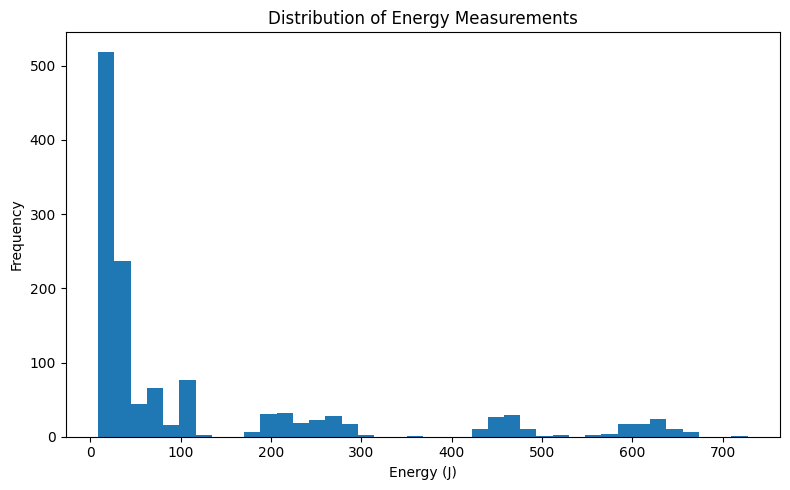

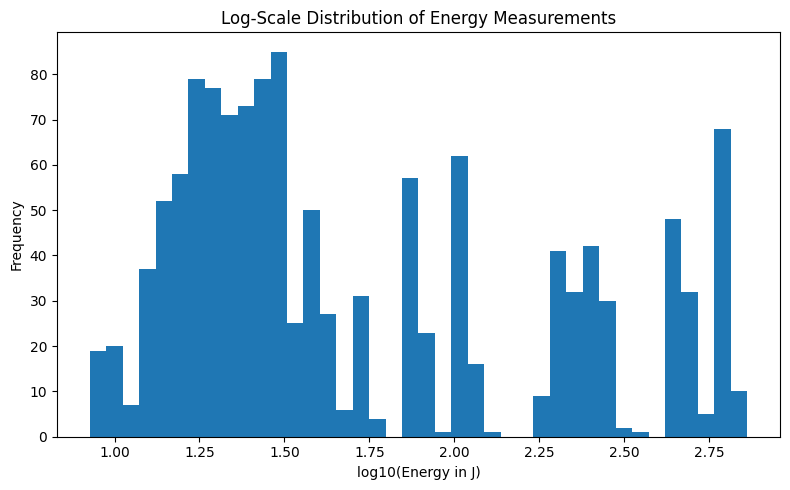

In [ ]:
# Energy distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["energy_j"], bins=40)
ax.set_xlabel("Energy (J)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Energy Measurements")
plt.tight_layout()
plt.show()

# Log-energy distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log10(df["energy_j"]), bins=40)
ax.set_xlabel("log10(Energy in J)")
ax.set_ylabel("Frequency")
ax.set_title("Log-Scale Distribution of Energy Measurements")
plt.tight_layout()
plt.show()

,n,mean_energy,median_energy,sd_energy,mean_runtime,mean_memory
engine,,,,,,
polars_eager,160,14.583508,14.312310,4.104361,1.258754,800.058252
polars_lazy,160,21.853480,21.047004,6.731254,1.711996,891.221558
duckdb,160,22.722920,22.346348,3.336495,1.714260,671.562769
pandas_numpy,160,30.880020,29.212908,11.542125,2.112045,1228.518701
pandas_pyarrow,160,31.800111,31.287335,11.652497,2.175845,1186.112231
python_loops,160,242.008379,234.464549,52.336311,17.668843,2005.425000
dask_default,160,309.146623,268.980146,226.904734,23.018842,738.970801
dask_pyarrow,160,325.847747,281.697674,240.691900,24.191595,712.624878


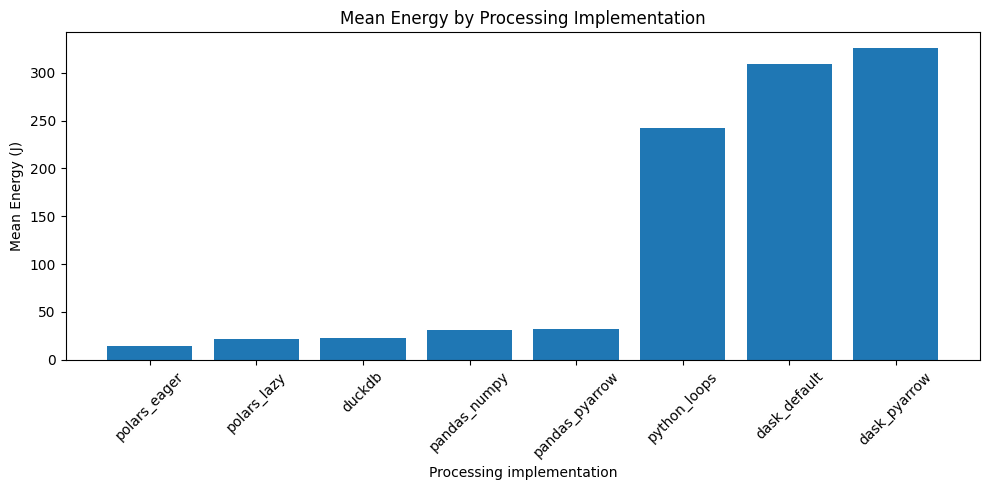

In [ ]:
# Mean energy by implementation
engine_summary = (
    df.groupby("engine", observed=True)
      .agg(
          n=("energy_j", "size"),
          mean_energy=("energy_j", "mean"),
          median_energy=("energy_j", "median"),
          sd_energy=("energy_j", "std"),
          mean_runtime=("runtime_s", "mean"),
          mean_memory=("peak_rss_mb", "mean")
      )
      .sort_values("mean_energy")
)

display(engine_summary)
engine_summary.to_csv(OUTPUT_DIR / "engine_summary.csv")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(engine_summary.index.astype(str), engine_summary["mean_energy"])
ax.set_ylabel("Mean Energy (J)")
ax.set_xlabel("Processing implementation")
ax.set_title("Mean Energy by Processing Implementation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 9. Main-effect descriptive summaries

In [ ]:
BINARY_FACTORS = ["data_format", "numeric_dtype", "categorical_dtype", "execution_mode"]

main_effect_tables = {}

for factor in BINARY_FACTORS:
    tab = (
        df.groupby(factor, observed=True)
          .agg(
              n=("energy_j", "size"),
              energy_mean=("energy_j", "mean"),
              energy_median=("energy_j", "median"),
              energy_sd=("energy_j", "std"),
              runtime_mean=("runtime_s", "mean"),
              memory_mean=("peak_rss_mb", "mean")
          )
    )
    main_effect_tables[factor] = tab
    print("\n", factor.upper())
    display(tab)
    tab.to_csv(OUTPUT_DIR / f"descriptive_main_effect_{factor}.csv")


 DATA_FORMAT


,n,energy_mean,energy_median,energy_sd,runtime_mean,memory_mean
data_format,,,,,,
csv,640,135.108448,35.508668,192.900987,10.126866,1012.039905
parquet,640,114.602250,23.774811,159.122780,8.336179,1046.583643



 NUMERIC_DTYPE


,n,energy_mean,energy_median,energy_sd,runtime_mean,memory_mean
numeric_dtype,,,,,,
float32,640,126.040892,31.485973,178.240803,9.300501,1023.210565
float64,640,123.669805,31.567729,175.979635,9.162544,1035.412982



 CATEGORICAL_DTYPE


,n,energy_mean,energy_median,energy_sd,runtime_mean,memory_mean
categorical_dtype,,,,,,
object,640,68.319583,34.821841,71.441747,4.929510,1076.171436
category,640,181.391115,29.135026,226.351316,13.533535,982.452112



 EXECUTION_MODE


,n,energy_mean,energy_median,energy_sd,runtime_mean,memory_mean
execution_mode,,,,,,
single,640,123.098935,29.897233,176.952118,9.341199,814.167987
parallel,640,126.611762,39.293295,177.265901,9.121846,1244.455560


## 10. Interaction plots

These plots are essential because the experiment tests whether the effect of a choice depends on the processing implementation.

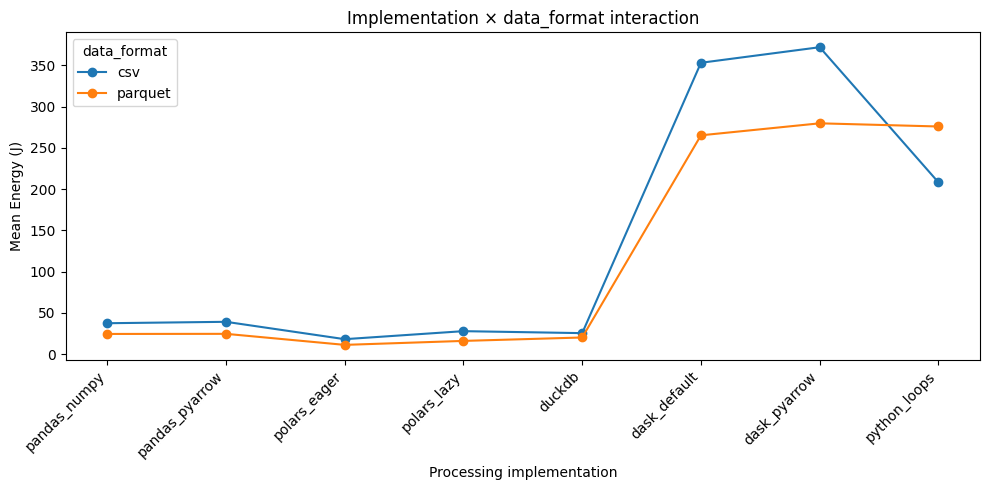

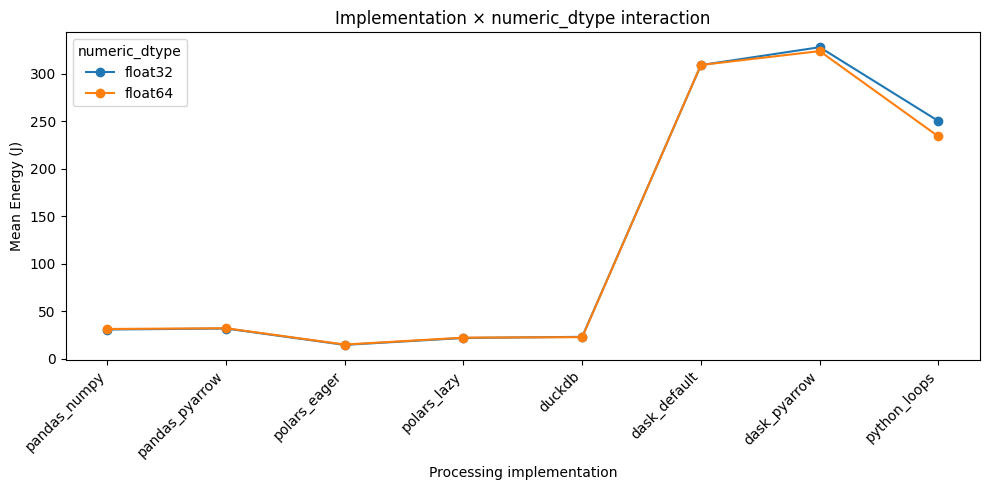

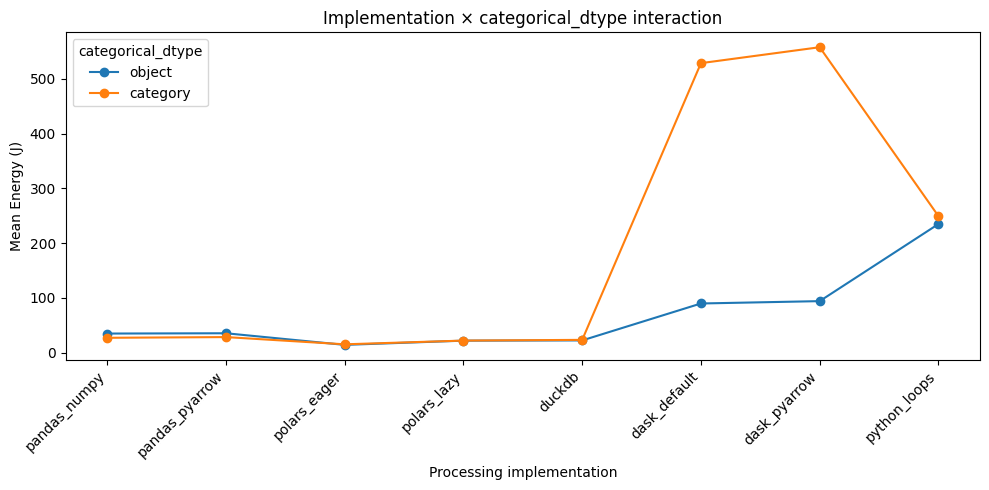

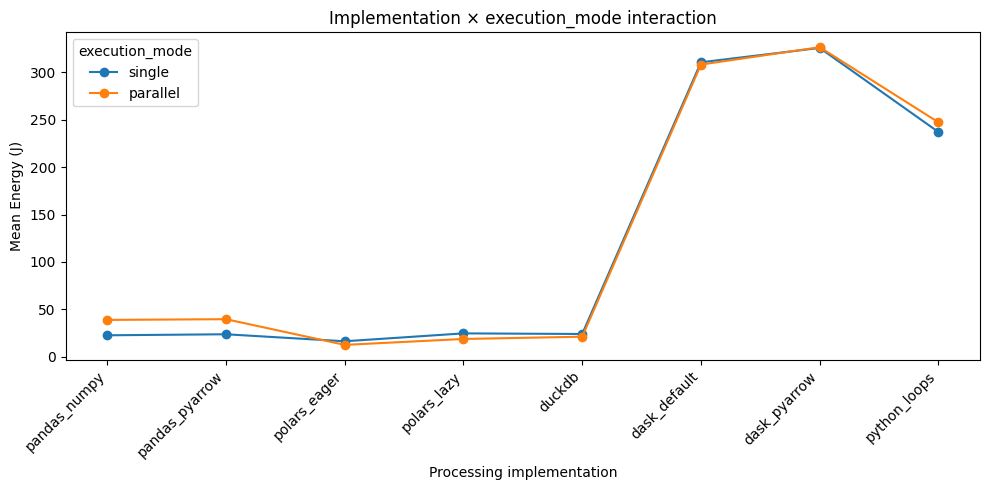

In [ ]:
def plot_engine_interaction(factor, outcome="energy_j", ylabel="Mean Energy (J)"):
    means = (
        df.groupby(["engine", factor], observed=True)[outcome]
          .mean()
          .unstack(factor)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(means.index))
    for level in means.columns:
        ax.plot(x, means[level].values, marker="o", label=str(level))
    ax.set_xticks(x)
    ax.set_xticklabels(means.index.astype(str), rotation=45, ha="right")
    ax.set_xlabel("Processing implementation")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Implementation × {factor} interaction")
    ax.legend(title=factor)
    plt.tight_layout()
    plt.show()

for f in ["data_format", "numeric_dtype", "categorical_dtype", "execution_mode"]:
    plot_engine_interaction(f)

## 11. Randomized-block diagnostics

,block,energy_mean,energy_median,runtime_mean,memory_mean
0,1,128.031612,32.514138,9.509439,1043.959137
1,2,124.689962,31.474193,9.495012,1033.828949
2,3,127.562305,32.317605,9.375923,1030.581329
3,4,120.177503,29.968887,8.997149,1027.873230
4,5,123.539760,30.102249,9.055173,1012.771698
5,6,125.767495,30.878126,9.199164,1026.491791
6,7,125.708991,32.017924,9.450923,1029.362091
7,8,123.373119,31.440624,9.188967,1034.093414
8,9,124.569048,31.902720,9.084137,1024.517670
9,10,125.133692,31.567729,8.959338,1029.638428


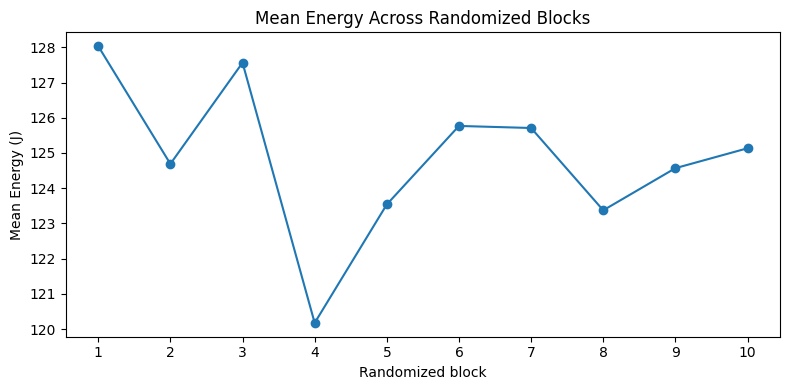

In [ ]:
block_summary = (
    df.groupby("block", observed=True)
      .agg(
          energy_mean=("energy_j", "mean"),
          energy_median=("energy_j", "median"),
          runtime_mean=("runtime_s", "mean"),
          memory_mean=("peak_rss_mb", "mean")
      )
      .reset_index()
)

display(block_summary)
block_summary.to_csv(OUTPUT_DIR / "block_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(block_summary["block"].astype(str), block_summary["energy_mean"], marker="o")
ax.set_xlabel("Randomized block")
ax.set_ylabel("Mean Energy (J)")
ax.set_title("Mean Energy Across Randomized Blocks")
plt.tight_layout()
plt.show()

# 12. Original-scale five-factor factorial model

For energy:

\[
Energy \sim Implementation \times Format \times NumericType \times
CategoricalRepresentation \times ExecutionMode + Block
\]

The model uses **sum-to-zero contrasts**, which are appropriate for Type III factorial tests.

The model is used for:

- fitted values and residuals;
- assumption diagnostics;
- sensitivity analysis;
- **partial eta-squared on the original joule scale**.

Because the assumptions are violated in this dataset, the original-scale ANOVA p-values should not be treated as the primary inferential evidence. The exact ART analysis later in the notebook is the primary significance analysis.

In [ ]:
FACTOR_FORMULA = (
    "C(engine, Sum) * "
    "C(data_format, Sum) * "
    "C(numeric_dtype, Sum) * "
    "C(categorical_dtype, Sum) * "
    "C(execution_mode, Sum)"
)

def fit_original_scale_model(data, outcome):
    formula = f"{outcome} ~ {FACTOR_FORMULA} + C(block, Sum)"
    model = smf.ols(formula, data=data).fit()
    table = anova_lm(model, typ=3)

    residual_ss = table.loc["Residual", "sum_sq"]
    table["partial_eta2"] = np.nan

    valid_terms = ~table.index.isin(["Intercept", "Residual"])
    table.loc[valid_terms, "partial_eta2"] = (
        table.loc[valid_terms, "sum_sq"]
        / (table.loc[valid_terms, "sum_sq"] + residual_ss)
    )

    table = table.reset_index().rename(columns={"index": "term"})
    return model, table

energy_model, energy_anova = fit_original_scale_model(df, "energy_j")

print(energy_model.summary().tables[0])
display(
    energy_anova.loc[
        ~energy_anova["term"].isin(["Intercept", "Residual"])
    ].sort_values("partial_eta2", ascending=False)
)

energy_anova.to_csv(
    OUTPUT_DIR / "energy_original_scale_type3_anova_partial_eta2.csv",
    index=False
)

                            OLS Regression Results                            
Dep. Variable:               energy_j   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     994.2
Date:                Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:39:57   Log-Likelihood:                -5381.3
No. Observations:                1280   AIC:                         1.104e+04
Df Residuals:                    1143   BIC:                         1.174e+04
Df Model:                         136                                         
Covariance Type:            nonrobust                                         


,term,sum_sq,df,F,PR(>F),partial_eta2
1,"C(engine, Sum)",2.220432e+07,7.0,10788.150277,0.000000e+00,0.985090
10,"C(engine, Sum):C(categorical_dtype, Sum)",1.223131e+07,7.0,5942.681464,0.000000e+00,0.973258
4,"C(categorical_dtype, Sum)",4.091255e+06,1.0,13914.388439,0.000000e+00,0.924090
7,"C(engine, Sum):C(data_format, Sum)",7.226496e+05,7.0,351.105258,1.433090e-279,0.682565
18,"C(engine, Sum):C(data_format, Sum):C(categoric...",2.294157e+05,7.0,111.463526,1.758875e-124,0.405692
2,"C(data_format, Sum)",1.345613e+05,1.0,457.644089,1.155367e-85,0.285912
11,"C(data_format, Sum):C(categorical_dtype, Sum)",7.076307e+04,1.0,240.665730,2.113226e-49,0.173933
13,"C(engine, Sum):C(execution_mode, Sum)",2.335917e+04,7.0,11.349245,5.698097e-14,0.064988
8,"C(engine, Sum):C(numeric_dtype, Sum)",9.423076e+03,7.0,4.578279,4.663856e-05,0.027274
6,"C(block, Sum)",5.756645e+03,9.0,2.175377,2.146624e-02,0.016840


## 13. Residual normality — Shapiro–Wilk + Q–Q plot

Residual:

\[
e_i = E_i - \hat{E}_i
\]

Shapiro–Wilk is applied to the **model residuals**, not directly to the raw 500,000-row telemetry dataset.

Shapiro–Wilk W = 0.350723
Shapiro–Wilk p = 3.304450e-55
Conclusion: residual normality is rejected at alpha = 0.05.


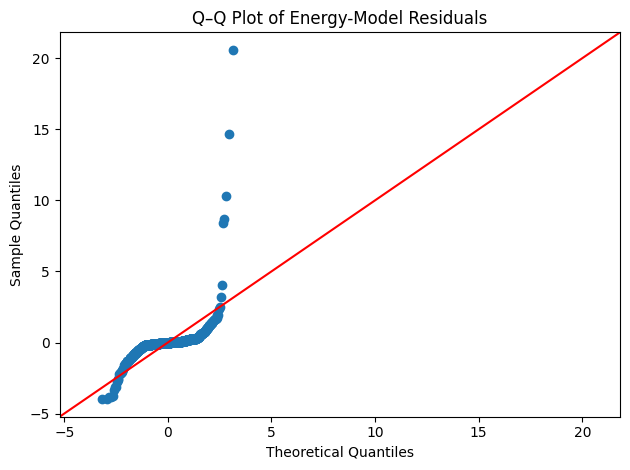

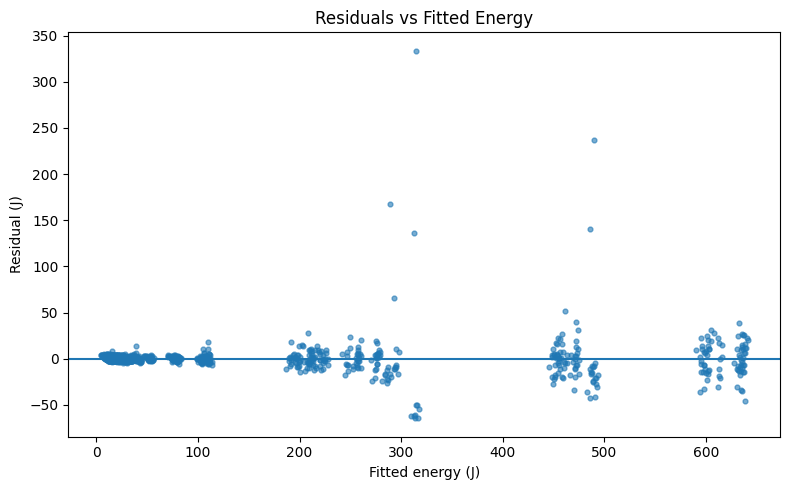

In [ ]:
energy_residuals = energy_model.resid
energy_fitted = energy_model.fittedvalues

shapiro_stat, shapiro_p = stats.shapiro(energy_residuals)

print(f"Shapiro–Wilk W = {shapiro_stat:.6f}")
print(f"Shapiro–Wilk p = {shapiro_p:.6e}")

if shapiro_p < 0.05:
    print("Conclusion: residual normality is rejected at alpha = 0.05.")
else:
    print("Conclusion: residual normality is not rejected at alpha = 0.05.")

fig = sm.qqplot(energy_residuals, line="45", fit=True)
plt.title("Q–Q Plot of Energy-Model Residuals")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(energy_fitted, energy_residuals, s=12, alpha=0.6)
ax.axhline(0)
ax.set_xlabel("Fitted energy (J)")
ax.set_ylabel("Residual (J)")
ax.set_title("Residuals vs Fitted Energy")
plt.tight_layout()
plt.show()

## 14. Homogeneity of variance - Levene and Brown–Forsythe

The classical Levene test uses deviations from the group mean.  
The median-centered version is commonly called the **Brown–Forsythe** variant and is more robust to skew/outliers.

Both are reported here. The 128 configurations are the groups.

In [ ]:
energy_groups = [
    g["energy_j"].to_numpy()
    for _, g in df.groupby("config_id", observed=True)
]

lev_mean_stat, lev_mean_p = stats.levene(*energy_groups, center="mean")
bf_stat, bf_p = stats.levene(*energy_groups, center="median")

variance_tests = pd.DataFrame([
    {
        "test": "Levene (mean-centered)",
        "statistic": lev_mean_stat,
        "p_value": lev_mean_p
    },
    {
        "test": "Brown-Forsythe / median-centered Levene",
        "statistic": bf_stat,
        "p_value": bf_p
    }
])

display(variance_tests)
variance_tests.to_csv(OUTPUT_DIR / "energy_variance_assumption_tests.csv", index=False)

,test,statistic,p_value
0,Levene (mean-centered),7.550521,5.220457e-86
1,Brown-Forsythe / median-centered Levene,2.446999,1.007084e-14


## 15. Assumption decision

The decision rule is:

- if residual normality and homogeneity are reasonably satisfied, ordinary factorial ANOVA can be the primary inferential model;
- if assumptions are substantially violated, **ART ANOVA** is used as the primary significance analysis.

The original-scale model remains useful for effect sizes and sensitivity interpretation.

In [ ]:
assumption_summary = pd.DataFrame([
    {"diagnostic": "Shapiro-Wilk residual normality", "p_value": shapiro_p},
    {"diagnostic": "Levene homogeneity", "p_value": lev_mean_p},
    {"diagnostic": "Brown-Forsythe homogeneity", "p_value": bf_p},
])

display(assumption_summary)

if (shapiro_p < 0.05) or (bf_p < 0.05):
    print("PRIMARY INFERENTIAL METHOD: ART ANOVA")
else:
    print("PRIMARY INFERENTIAL METHOD: original-scale factorial ANOVA")

,diagnostic,p_value
0,Shapiro-Wilk residual normality,3.304450e-55
1,Levene homogeneity,5.220457e-86
2,Brown-Forsythe homogeneity,1.007084e-14


PRIMARY INFERENTIAL METHOD: ART ANOVA


# 16. Runtime and memory: original-scale models, assumptions, and effect sizes

The same factorial structure is applied to the two secondary outcomes.

In [ ]:
secondary_results = {}

for outcome in ["runtime_s", "peak_rss_mb"]:
    model, table = fit_original_scale_model(df, outcome)

    groups = [
        g[outcome].to_numpy()
        for _, g in df.groupby("config_id", observed=True)
    ]

    sh = stats.shapiro(model.resid)
    lev = stats.levene(*groups, center="mean")
    bf = stats.levene(*groups, center="median")

    secondary_results[outcome] = {
        "model": model,
        "anova": table,
        "shapiro_W": sh.statistic,
        "shapiro_p": sh.pvalue,
        "levene_stat": lev.statistic,
        "levene_p": lev.pvalue,
        "brown_forsythe_stat": bf.statistic,
        "brown_forsythe_p": bf.pvalue,
    }

    print("\nOUTCOME:", outcome)
    print(f"Shapiro p          = {sh.pvalue:.6e}")
    print(f"Levene p           = {lev.pvalue:.6e}")
    print(f"Brown-Forsythe p   = {bf.pvalue:.6e}")

    display(
        table.loc[
            ~table["term"].isin(["Intercept", "Residual"])
        ].sort_values("partial_eta2", ascending=False).head(15)
    )

    table.to_csv(
        OUTPUT_DIR / f"{outcome}_original_scale_type3_anova_partial_eta2.csv",
        index=False
    )

secondary_assumptions = pd.DataFrame([
    {
        "outcome": outcome,
        "shapiro_p": r["shapiro_p"],
        "levene_p": r["levene_p"],
        "brown_forsythe_p": r["brown_forsythe_p"]
    }
    for outcome, r in secondary_results.items()
])

secondary_assumptions.to_csv(
    OUTPUT_DIR / "secondary_outcome_assumption_tests.csv",
    index=False
)


OUTCOME: runtime_s
Shapiro p          = 4.472943e-54
Levene p           = 8.219736e-74
Brown-Forsythe p   = 9.235965e-22


,term,sum_sq,df,F,PR(>F),partial_eta2
1,"C(engine, Sum)",121947.105541,7.0,15411.184768,0.000000e+00,0.989516
10,"C(engine, Sum):C(categorical_dtype, Sum)",70447.052637,7.0,8902.815198,0.000000e+00,0.981989
4,"C(categorical_dtype, Sum)",23689.361355,1.0,20956.363522,0.000000e+00,0.948279
7,"C(engine, Sum):C(data_format, Sum)",5095.267259,7.0,643.919385,0.000000e+00,0.797715
18,"C(engine, Sum):C(data_format, Sum):C(categoric...",2105.400612,7.0,266.072062,7.934858e-235,0.619698
2,"C(data_format, Sum)",1026.099614,1.0,907.720398,2.939047e-147,0.442635
11,"C(data_format, Sum):C(categorical_dtype, Sum)",658.612925,1.0,582.629969,2.321042e-104,0.337633
13,"C(engine, Sum):C(execution_mode, Sum)",166.501495,7.0,21.041789,8.869583e-27,0.114154
6,"C(block, Sum)",51.244459,9.0,5.036942,1.097532e-06,0.038148
8,"C(engine, Sum):C(numeric_dtype, Sum)",46.079911,7.0,5.823394,1.182944e-06,0.034436



OUTCOME: peak_rss_mb
Shapiro p          = 6.182513e-53
Levene p           = 0.000000e+00
Brown-Forsythe p   = 7.099583e-159


,term,sum_sq,df,F,PR(>F),partial_eta2
1,"C(engine, Sum)",2.242025e+08,7.0,3571.778011,0.000000e+00,0.956283
13,"C(engine, Sum):C(execution_mode, Sum)",5.998375e+07,7.0,955.603239,0.000000e+00,0.854064
5,"C(execution_mode, Sum)",5.924717e+07,1.0,6607.080599,0.000000e+00,0.852518
10,"C(engine, Sum):C(categorical_dtype, Sum)",1.023378e+07,7.0,163.034689,5.956439e-167,0.499615
4,"C(categorical_dtype, Sum)",2.810660e+06,1.0,313.437020,3.607689e-62,0.215208
7,"C(engine, Sum):C(data_format, Sum)",2.445958e+06,7.0,38.966634,2.991965e-49,0.192663
21,"C(engine, Sum):C(data_format, Sum):C(execution...",1.564732e+06,7.0,24.927798,8.487521e-32,0.132444
24,"C(engine, Sum):C(categorical_dtype, Sum):C(exe...",1.143391e+06,7.0,18.215397,4.422022e-23,0.100360
14,"C(data_format, Sum):C(execution_mode, Sum)",4.045885e+05,1.0,45.118589,2.917399e-11,0.037975
2,"C(data_format, Sum)",3.818463e+05,1.0,42.582451,1.016123e-10,0.035917


# 17. Exact ART ANOVA and ART-C in R

Python does not provide a standard, validated implementation of ART-C comparable to **ARTool**.  
This section therefore installs R and uses the CRAN `ARTool` package.

The exact energy model is:

\[
Energy \sim Engine \times Format \times Numeric \times Category \times Execution
+ (1|Block)
\]

`Block` is included as a random intercept in the ART mixed model.

The R section:

1. fits exact ART models;
2. verifies the alignment diagnostics;
3. exports Type III ART ANOVA tables;
4. performs exact ART-C contrasts;
5. applies Holm correction to the selected within-engine simple-effect families.

**Energy is primary.** ART is also run for runtime and memory because both secondary outcomes violate the same assumptions.

In [ ]:
# Save a clean analysis CSV for R.
r_cols = [
    "block", "engine", "data_format", "numeric_dtype",
    "categorical_dtype", "execution_mode",
    "energy_j", "runtime_s", "peak_rss_mb"
]

R_DATA_PATH = BASE_DIR / "cse407_clean_for_r.csv"
df[r_cols].to_csv(R_DATA_PATH, index=False)
print("Saved R input:", R_DATA_PATH)

Saved R input: /content/cse407_clean_for_r.csv


### 17.1 Install R + ARTool

This cell is intended for Google Colab. The first installation can take several minutes.

In [ ]:
import shutil, subprocess, os, textwrap

if shutil.which("Rscript") is None:
    print("Installing R...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "r-base", "r-base-dev"],
        check=True
    )

# Try Ubuntu binary packages first to reduce compilation time.
apt_r_packages = [
    "r-cran-lme4", "r-cran-car", "r-cran-emmeans",
    "r-cran-dplyr", "r-cran-lmertest"
]

for pkg in apt_r_packages:
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", pkg],
        check=False,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

install_r = r'''
needed <- c("ARTool", "emmeans", "dplyr", "lme4")
installed <- rownames(installed.packages())
missing <- setdiff(needed, installed)
if (length(missing) > 0) {
    install.packages(missing, repos="https://cloud.r-project.org", dependencies=TRUE)
}
cat("ARTool version:", as.character(packageVersion("ARTool")), "\n")
'''

subprocess.run(["Rscript", "-e", install_r], check=True)
print("R/ARTool setup complete.")

R/ARTool setup complete.


### 17.2 Run exact ART ANOVA + ART-C

Selected energy post-hoc families:

- all 28 pairwise implementation comparisons, Holm corrected;
- CSV vs Parquet **within each implementation**;
- Float32 vs Float64 **within each implementation**;
- object vs category **within each implementation**;
- single vs parallel **within each implementation**.

The four within-engine families use ART-C alignment for `engine:factor`, retain only the preselected same-engine contrasts, and apply Holm correction across the eight implementations in that family.

In [ ]:
r_script = r'''
suppressPackageStartupMessages({
    library(ARTool)
    library(emmeans)
    library(dplyr)
    library(lme4)
})

options(contrasts = c("contr.sum", "contr.poly"))

data_path <- Sys.getenv("CSE407_R_DATA_PATH")
out_dir <- Sys.getenv("CSE407_OUTPUT_DIR")

d <- read.csv(data_path, stringsAsFactors = FALSE)

# Explicit factor conversion
d$block <- factor(d$block)
d$engine <- factor(
    d$engine,
    levels=c(
        "pandas_numpy", "pandas_pyarrow", "polars_eager", "polars_lazy",
        "duckdb", "dask_default", "dask_pyarrow", "python_loops"
    )
)
d$data_format <- factor(d$data_format, levels=c("csv", "parquet"))
d$numeric_dtype <- factor(d$numeric_dtype, levels=c("float32", "float64"))
d$categorical_dtype <- factor(d$categorical_dtype, levels=c("object", "category"))
d$execution_mode <- factor(d$execution_mode, levels=c("single", "parallel"))

fixed_rhs <- paste(
    "engine * data_format * numeric_dtype * categorical_dtype * execution_mode"
)

fit_art_model <- function(response, prefix) {
    f <- as.formula(
        paste(response, "~", fixed_rhs, "+ (1|block)")
    )

    cat("\n============================================================\n")
    cat("Fitting ART model for:", response, "\n")
    cat("============================================================\n")

    m <- art(f, data=d)

    # Alignment diagnostics: sums should be ~0 and F values of
    # non-target effects on aligned responses should be ~0.
    capture.output(
        summary(m),
        file=file.path(out_dir, paste0(prefix, "_art_alignment_diagnostics.txt"))
    )

    a <- anova(m, type="III")
    a_df <- as.data.frame(a)
    a_df$term <- rownames(a_df)
    rownames(a_df) <- NULL
    a_df <- a_df[, c("term", setdiff(names(a_df), "term"))]

    write.csv(
        a_df,
        file.path(out_dir, paste0(prefix, "_exact_ART_ANOVA.csv")),
        row.names=FALSE
    )

    saveRDS(
        m,
        file.path(out_dir, paste0(prefix, "_ART_model.rds"))
    )

    print(a)
    return(m)
}

# Primary outcome
m_energy <- fit_art_model("energy_j", "energy")

# Secondary outcomes
m_runtime <- fit_art_model("runtime_s", "runtime")
m_memory <- fit_art_model("peak_rss_mb", "memory")

# ------------------------------------------------------------
# Exact ART-C: engine main-effect pairwise comparisons
# ------------------------------------------------------------
engine_pairwise <- as.data.frame(
    summary(
        art.con(
            m_energy,
            "engine",
            method="pairwise",
            adjust="holm"
        )
    )
)

write.csv(
    engine_pairwise,
    file.path(out_dir, "energy_ARTC_engine_pairwise_Holm.csv"),
    row.names=FALSE
)

# ------------------------------------------------------------
# Selected exact ART-C simple effects:
# compare the binary factor within the SAME engine.
#
# art.con(engine:factor) constructs the correct ART-C aligned
# model for combinations of those factors. We request unadjusted
# pairwise p-values, retain only the eight preselected same-engine
# contrasts, then Holm-correct that selected family.
# ------------------------------------------------------------

get_engine_from_combo <- function(x, engine_levels) {
    x <- trimws(x)

    for (e in engine_levels) {
        # Current ARTool labels combinations like "engine,level".
        if (startsWith(x, paste0(e, ","))) return(e)

        # Fallback for alternate printing with a space separator.
        if (startsWith(x, paste0(e, " "))) return(e)

        if (identical(x, e)) return(e)
    }

    return(NA_character_)
}

selected_simple_effects <- function(model, factor_name, filename) {
    term <- paste0("engine:", factor_name)

    raw <- as.data.frame(
        summary(
            art.con(
                model,
                term,
                method="pairwise",
                adjust="none"
            )
        )
    )

    contrast_text <- as.character(raw$contrast)
    split_contrast <- strsplit(contrast_text, " - ", fixed=TRUE)

    lhs <- vapply(
        split_contrast,
        function(z) if (length(z) >= 1) trimws(z[1]) else NA_character_,
        character(1)
    )

    rhs <- vapply(
        split_contrast,
        function(z) if (length(z) >= 2) trimws(z[2]) else NA_character_,
        character(1)
    )

    engine_levels <- levels(d$engine)

    lhs_engine <- vapply(
        lhs, get_engine_from_combo, character(1),
        engine_levels=engine_levels
    )
    rhs_engine <- vapply(
        rhs, get_engine_from_combo, character(1),
        engine_levels=engine_levels
    )

    keep <- !is.na(lhs_engine) & !is.na(rhs_engine) &
            lhs_engine == rhs_engine

    selected <- raw[keep, , drop=FALSE]
    selected$engine <- lhs_engine[keep]

    if (nrow(selected) != length(engine_levels)) {
        warning(
            paste0(
                filename,
                ": expected ",
                length(engine_levels),
                " same-engine contrasts, found ",
                nrow(selected),
                ". Inspect the unfiltered ART-C table."
            )
        )
    }

    selected$p_holm <- p.adjust(selected$p.value, method="holm")
    selected$significant_holm_0_05 <- selected$p_holm < 0.05

    write.csv(
        raw,
        file.path(out_dir, paste0(filename, "_ALL_ARTC_combinations_unadjusted.csv")),
        row.names=FALSE
    )

    write.csv(
        selected,
        file.path(out_dir, paste0(filename, "_selected_within_engine_Holm.csv")),
        row.names=FALSE
    )

    return(selected)
}

format_simple <- selected_simple_effects(
    m_energy, "data_format", "energy_ARTC_engine_by_format"
)

numeric_simple <- selected_simple_effects(
    m_energy, "numeric_dtype", "energy_ARTC_engine_by_numeric"
)

category_simple <- selected_simple_effects(
    m_energy, "categorical_dtype", "energy_ARTC_engine_by_category"
)

execution_simple <- selected_simple_effects(
    m_energy, "execution_mode", "energy_ARTC_engine_by_execution"
)

cat("\nSelected ART-C: format within engine\n")
print(format_simple)

cat("\nSelected ART-C: numeric type within engine\n")
print(numeric_simple)

cat("\nSelected ART-C: category representation within engine\n")
print(category_simple)

cat("\nSelected ART-C: execution mode within engine\n")
print(execution_simple)
'''

R_SCRIPT_PATH = BASE_DIR / "run_cse407_art.R"
R_SCRIPT_PATH.write_text(r_script)

print("Running exact ART/ART-C. This is the most computationally intensive section...")
r_env = os.environ.copy()
r_env["CSE407_R_DATA_PATH"] = str(R_DATA_PATH)
r_env["CSE407_OUTPUT_DIR"] = str(OUTPUT_DIR)
subprocess.run(["Rscript", str(R_SCRIPT_PATH)], check=True, env=r_env)
print("Exact ART/ART-C completed.")

Running exact ART/ART-C. This is the most computationally intensive section...
Exact ART/ART-C completed.


## 18. Read the exact ART results back into Python

In [ ]:
def read_if_exists(filename):
    path = OUTPUT_DIR / filename
    if path.exists():
        return pd.read_csv(path)
    print("Missing:", path)
    return None

energy_art = read_if_exists("energy_exact_ART_ANOVA.csv")
runtime_art = read_if_exists("runtime_exact_ART_ANOVA.csv")
memory_art = read_if_exists("memory_exact_ART_ANOVA.csv")

print("ENERGY — exact ART ANOVA")
if energy_art is not None:
    display(energy_art)

print("\nRUNTIME — exact ART ANOVA")
if runtime_art is not None:
    display(runtime_art)

print("\nMEMORY — exact ART ANOVA")
if memory_art is not None:
    display(memory_art)

for filename in [
    "energy_ARTC_engine_pairwise_Holm.csv",
    "energy_ARTC_engine_by_format_selected_within_engine_Holm.csv",
    "energy_ARTC_engine_by_numeric_selected_within_engine_Holm.csv",
    "energy_ARTC_engine_by_category_selected_within_engine_Holm.csv",
    "energy_ARTC_engine_by_execution_selected_within_engine_Holm.csv",
]:
    tab = read_if_exists(filename)
    if tab is not None:
        print("\n", filename)
        display(tab)

ENERGY — exact ART ANOVA


,term,Term,F,Df,Df.res,Pr(>F)
0,engine,engine,5205.887099,7,1143.0,0.000000e+00
1,data_format,data_format,2795.666071,1,1143.0,2.390417e-309
2,numeric_dtype,numeric_dtype,371.766285,1,1143.0,6.061699e-72
3,categorical_dtype,categorical_dtype,4963.493501,1,1143.0,0.000000e+00
4,execution_mode,execution_mode,525.789676,1,1143.0,4.939691e-96
5,engine:data_format,engine:data_format,2174.313866,7,1143.0,0.000000e+00
6,engine:numeric_dtype,engine:numeric_dtype,64.187273,7,1143.0,5.246904e-78
7,data_format:numeric_dtype,data_format:numeric_dtype,0.011066,1,1143.0,9.162395e-01
8,engine:categorical_dtype,engine:categorical_dtype,3631.531538,7,1143.0,0.000000e+00
9,data_format:categorical_dtype,data_format:categorical_dtype,2048.090188,1,1143.0,4.376660e-257



RUNTIME — exact ART ANOVA


,term,Term,F,Df,Df.res,Pr(>F)
0,engine,engine,4873.704684,7,1143.0,0.000000e+00
1,data_format,data_format,3172.849218,1,1143.0,0.000000e+00
2,numeric_dtype,numeric_dtype,296.581725,1,1143.0,2.856139e-59
3,categorical_dtype,categorical_dtype,5685.269296,1,1143.0,0.000000e+00
4,execution_mode,execution_mode,475.468854,1,1143.0,2.033260e-88
5,engine:data_format,engine:data_format,4681.025743,7,1143.0,0.000000e+00
6,engine:numeric_dtype,engine:numeric_dtype,56.919909,7,1143.0,4.833665e-70
7,data_format:numeric_dtype,data_format:numeric_dtype,87.323635,1,1143.0,4.675066e-20
8,engine:categorical_dtype,engine:categorical_dtype,3806.660630,7,1143.0,0.000000e+00
9,data_format:categorical_dtype,data_format:categorical_dtype,2580.352725,1,1143.0,2.171792e-295



MEMORY — exact ART ANOVA


...

,contrast,estimate,SE,df,t.ratio,p.value,engine,p_holm,significant_holm_0_05
0,"dask_default,float32 - dask_default,float64",3.9750,10.56727,1143.0,0.376161,0.706867,dask_default,1.000000,False
1,"dask_pyarrow,float32 - dask_pyarrow,float64",4.4125,10.56727,1143.0,0.417563,0.676345,dask_pyarrow,1.000000,False
2,"duckdb,float32 - duckdb,float64",18.4125,10.56727,1143.0,1.742408,0.081706,duckdb,0.245118,False
3,"pandas_numpy,float32 - pandas_numpy,float64",-33.8375,10.56727,1143.0,-3.202104,0.001402,pandas_numpy,0.009813,True
4,"pandas_pyarrow,float32 - pandas_pyarrow,float64",-22.7125,10.56727,1143.0,-2.149325,0.031818,pandas_pyarrow,0.127272,False
5,"polars_eager,float32 - polars_eager,float64",-23.7000,10.56727,1143.0,-2.242774,0.025102,polars_eager,0.125512,False
6,"polars_lazy,float32 - polars_lazy,float64",-33.4625,10.56727,1143.0,-3.166617,0.001583,polars_lazy,0.009813,True
7,"python_loops,float32 - python_loops,float64",48.0875,10.56727,1143.0,4.550608,0.000006,python_loops,0.000047,True



 energy_ARTC_engine_by_category_selected_within_engine_Holm.csv


,contrast,estimate,SE,df,t.ratio,p.value,engine,p_holm,significant_holm_0_05
0,"dask_default,category - dask_default,object",319.7500,7.718123,1143.0,41.428464,7.995749e-230,dask_default,6.396599e-229,True
1,"dask_pyarrow,category - dask_pyarrow,object",318.3500,7.718123,1143.0,41.247073,1.617365e-228,dask_pyarrow,1.132156e-227,True
2,"duckdb,category - duckdb,object",69.6625,7.718123,1143.0,9.025834,7.380224e-19,duckdb,2.952089e-18,True
3,"pandas_numpy,category - pandas_numpy,object",-176.8000,7.718123,1143.0,-22.907123,7.091200e-96,pandas_numpy,4.254720e-95,True
4,"pandas_pyarrow,category - pandas_pyarrow,object",-141.2875,7.718123,1143.0,-18.305939,7.590011e-66,pandas_pyarrow,3.795006e-65,True
5,"polars_eager,category - polars_eager,object",57.0875,7.718123,1143.0,7.396552,2.697898e-13,polars_eager,8.093695e-13,True
6,"polars_lazy,category - polars_lazy,object",7.8625,7.718123,1143.0,1.018706,3.085581e-01,polars_lazy,3.085581e-01,False
7,"python_loops,category - python_loops,object",45.6000,7.718123,1143.0,5.908172,4.559058e-09,python_loops,9.118117e-09,True



 energy_ARTC_engine_by_execution_selected_within_engine_Holm.csv


,contrast,estimate,SE,df,t.ratio,p.value,engine,p_holm,significant_holm_0_05
0,"dask_default,parallel - dask_default,single",-22.3250,9.361488,1143.0,-2.384771,1.725206e-02,dask_default,3.450412e-02,True
1,"dask_pyarrow,parallel - dask_pyarrow,single",0.7875,9.361488,1143.0,0.084121,9.329748e-01,dask_pyarrow,9.329748e-01,False
2,"duckdb,parallel - duckdb,single",-189.1250,9.361488,1143.0,-20.202451,7.554707e-78,duckdb,3.777354e-77,True
3,"pandas_numpy,parallel - pandas_numpy,single",339.1500,9.361488,1143.0,36.228216,5.231365e-192,pandas_numpy,3.661955e-191,True
4,"pandas_pyarrow,parallel - pandas_pyarrow,single",261.5250,9.361488,1143.0,27.936265,2.461926e-131,pandas_pyarrow,1.477156e-130,True
5,"polars_eager,parallel - polars_eager,single",-78.9250,9.361488,1143.0,-8.430818,1.022186e-16,polars_eager,4.088742e-16,True
6,"polars_lazy,parallel - polars_lazy,single",-346.5750,9.361488,1143.0,-37.021359,8.132705e-198,polars_lazy,6.506164e-197,True
7,"python_loops,parallel - python_loops,single",34.7625,9.361488,1143.0,3.713352,2.143992e-04,python_loops,6.431977e-04,True


# 19. Energy–runtime relationship, average power, and energy-delay product

\[
Average\ Power = \frac{Energy}{Runtime}
\]

\[
EDP = Energy \times Runtime
\]

This distinguishes energy savings caused mainly by finishing faster from savings associated with lower average power.

,level,method,statistic,p_value
0,run-level,Pearson,0.993715,0.000000e+00
1,run-level,Spearman,0.989986,0.000000e+00
2,configuration-mean,Pearson,0.998709,5.981853e-165
3,configuration-mean,Spearman,0.989133,8.828026e-107


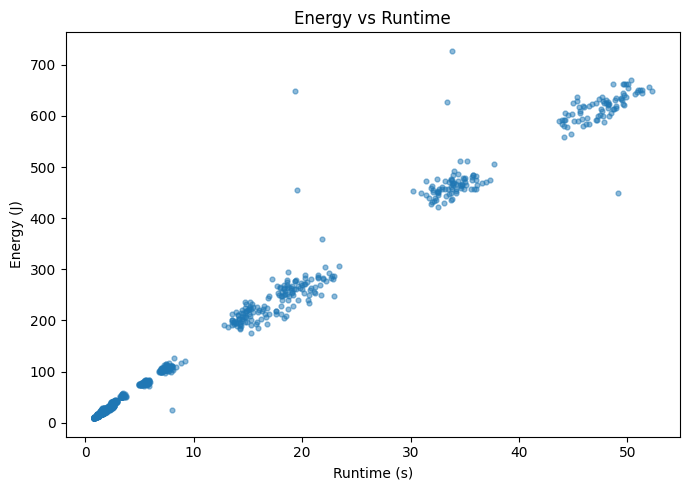

,config_id,engine,data_format,numeric_dtype,categorical_dtype,execution_mode,mean_energy,mean_runtime,mean_memory,mean_power,mean_edp
90,polars_eager__parquet__float32__object__parallel,polars_eager,parquet,float32,object,parallel,8.980440,0.791188,806.450000,11.346831,7.113100
94,polars_eager__parquet__float64__object__parallel,polars_eager,parquet,float64,object,parallel,9.365998,0.807243,820.430859,11.597710,7.566262
88,polars_eager__parquet__float32__category__para...,polars_eager,parquet,float32,category,parallel,9.851299,0.830710,812.079687,11.853242,8.190747
92,polars_eager__parquet__float64__category__para...,polars_eager,parquet,float64,category,parallel,9.971642,0.851494,806.482422,11.715965,8.500405
91,polars_eager__parquet__float32__object__single,polars_eager,parquet,float32,object,single,12.260137,1.119293,745.655859,10.938369,13.757966
95,polars_eager__parquet__float64__object__single,polars_eager,parquet,float64,object,single,12.263879,1.113768,729.522656,11.007414,13.670964
89,polars_eager__parquet__float32__category__single,polars_eager,parquet,float32,category,single,13.115866,1.202625,761.370312,10.906035,15.788774
93,polars_eager__parquet__float64__category__single,polars_eager,parquet,float64,category,single,13.232681,1.199002,742.427734,11.037540,15.871150
106,polars_lazy__parquet__float32__object__parallel,polars_lazy,parquet,float32,object,parallel,13.519588,1.066129,946.704687,12.675087,14.425763
104,polars_lazy__parquet__float32__category__parallel,polars_lazy,parquet,float32,category,parallel,13.576534,1.072658,919.687109,12.658530,14.579084


In [ ]:
df["avg_power_w"] = df["energy_j"] / df["runtime_s"]
df["edp_j_s"] = df["energy_j"] * df["runtime_s"]

pearson_raw = stats.pearsonr(df["energy_j"], df["runtime_s"])
spearman_raw = stats.spearmanr(df["energy_j"], df["runtime_s"])

relationship = pd.DataFrame([
    {
        "level": "run-level",
        "method": "Pearson",
        "statistic": pearson_raw.statistic,
        "p_value": pearson_raw.pvalue,
    },
    {
        "level": "run-level",
        "method": "Spearman",
        "statistic": spearman_raw.statistic,
        "p_value": spearman_raw.pvalue,
    }
])

# Configuration-level relation
cfg_rel = config_summary[["config_id", "energy_mean", "runtime_mean"]].copy()

pearson_cfg = stats.pearsonr(cfg_rel["energy_mean"], cfg_rel["runtime_mean"])
spearman_cfg = stats.spearmanr(cfg_rel["energy_mean"], cfg_rel["runtime_mean"])

relationship = pd.concat([
    relationship,
    pd.DataFrame([
        {
            "level": "configuration-mean",
            "method": "Pearson",
            "statistic": pearson_cfg.statistic,
            "p_value": pearson_cfg.pvalue,
        },
        {
            "level": "configuration-mean",
            "method": "Spearman",
            "statistic": spearman_cfg.statistic,
            "p_value": spearman_cfg.pvalue,
        }
    ])
], ignore_index=True)

display(relationship)
relationship.to_csv(OUTPUT_DIR / "energy_runtime_correlations.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["runtime_s"], df["energy_j"], s=12, alpha=0.5)
ax.set_xlabel("Runtime (s)")
ax.set_ylabel("Energy (J)")
ax.set_title("Energy vs Runtime")
plt.tight_layout()
plt.show()

derived_summary = (
    df.groupby(CONFIG_FACTORS, observed=True)
      .agg(
          mean_energy=("energy_j", "mean"),
          mean_runtime=("runtime_s", "mean"),
          mean_memory=("peak_rss_mb", "mean"),
          mean_power=("avg_power_w", "mean"),
          mean_edp=("edp_j_s", "mean")
      )
      .reset_index()
      .sort_values("mean_energy")
)

display(derived_summary.head(15))
derived_summary.to_csv(
    OUTPUT_DIR / "configuration_energy_runtime_power_edp.csv",
    index=False
)

# 20. Pareto analysis

A configuration is Pareto-efficient if no other configuration is simultaneously equal or better in all selected outcomes and strictly better in at least one.

The notebook reports:

- energy–runtime Pareto frontier;
- energy–runtime–memory Pareto frontier.

Energy-runtime Pareto configurations: 1
Energy-runtime-memory Pareto configurations: 10


,config_id,engine,data_format,numeric_dtype,categorical_dtype,execution_mode,energy_mean,runtime_mean,memory_mean,pareto_energy_runtime,pareto_energy_runtime_memory
0,polars_eager__parquet__float32__object__parallel,polars_eager,parquet,float32,object,parallel,8.980440,0.791188,806.450000,True,True
4,polars_eager__parquet__float32__object__single,polars_eager,parquet,float32,object,single,12.260137,1.119293,745.655859,False,True
5,polars_eager__parquet__float64__object__single,polars_eager,parquet,float64,object,single,12.263879,1.113768,729.522656,False,True
13,pandas_numpy__parquet__float64__category__single,pandas_numpy,parquet,float64,category,single,14.992998,1.109505,605.326172,False,True
14,pandas_numpy__parquet__float32__category__single,pandas_numpy,parquet,float32,category,single,15.072538,1.128804,574.865234,False,True
15,pandas_pyarrow__parquet__float32__category__si...,pandas_pyarrow,parquet,float32,category,single,15.135917,1.134358,571.130469,False,True
16,pandas_pyarrow__parquet__float64__category__si...,pandas_pyarrow,parquet,float64,category,single,15.297855,1.129139,571.142969,False,True
56,pandas_numpy__csv__float32__category__single,pandas_numpy,csv,float32,category,single,27.767855,2.035533,545.701563,False,True
57,pandas_numpy__csv__float64__category__single,pandas_numpy,csv,float64,category,single,28.050002,2.029207,547.853125,False,True
58,pandas_pyarrow__csv__float32__category__single,pandas_pyarrow,csv,float32,category,single,29.847995,2.150174,519.730859,False,True


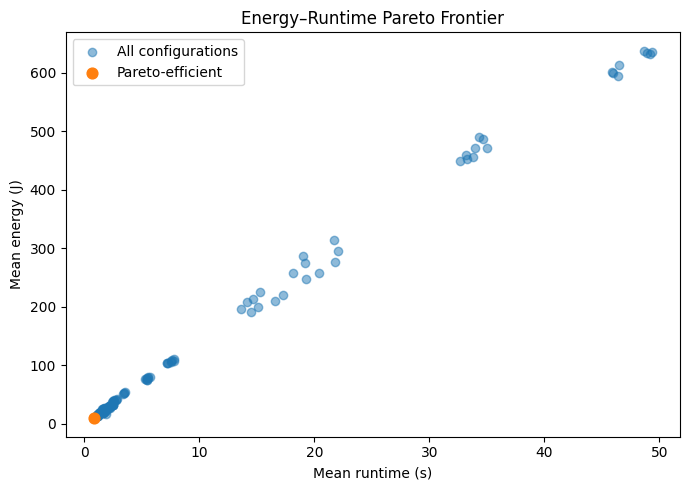

In [ ]:
pareto_base = config_summary[
    [
        "config_id", "engine", "data_format", "numeric_dtype",
        "categorical_dtype", "execution_mode",
        "energy_mean", "runtime_mean", "memory_mean"
    ]
].copy()

def pareto_mask(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if not efficient[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            # j dominates i if j <= i on all dimensions and < on at least one
            if np.all(values[j] <= values[i]) and np.any(values[j] < values[i]):
                efficient[i] = False
                break

    return efficient

pareto_base["pareto_energy_runtime"] = pareto_mask(
    pareto_base[["energy_mean", "runtime_mean"]].to_numpy()
)

pareto_base["pareto_energy_runtime_memory"] = pareto_mask(
    pareto_base[["energy_mean", "runtime_mean", "memory_mean"]].to_numpy()
)

print("Energy-runtime Pareto configurations:",
      pareto_base["pareto_energy_runtime"].sum())
print("Energy-runtime-memory Pareto configurations:",
      pareto_base["pareto_energy_runtime_memory"].sum())

display(
    pareto_base.loc[
        pareto_base["pareto_energy_runtime_memory"]
    ].sort_values("energy_mean")
)

pareto_base.to_csv(OUTPUT_DIR / "pareto_analysis.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    pareto_base["runtime_mean"],
    pareto_base["energy_mean"],
    alpha=0.5,
    label="All configurations"
)

front = pareto_base.loc[pareto_base["pareto_energy_runtime"]].sort_values("runtime_mean")
ax.scatter(
    front["runtime_mean"],
    front["energy_mean"],
    s=60,
    label="Pareto-efficient"
)
ax.plot(front["runtime_mean"], front["energy_mean"])

ax.set_xlabel("Mean runtime (s)")
ax.set_ylabel("Mean energy (J)")
ax.set_title("Energy–Runtime Pareto Frontier")
ax.legend()
plt.tight_layout()
plt.show()

# 21. Position-in-block drift

Because run order was randomized inside each block, systematic correlation between position and model residuals should be weak.

This analysis tests whether residual energy still drifts with run position.

Spearman(position, energy residual) = 0.0385, p = 0.168485


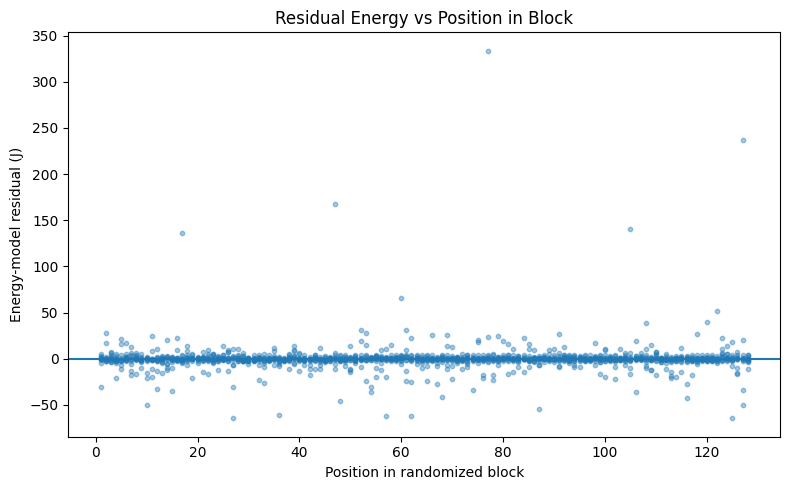

In [ ]:
position_spearman = stats.spearmanr(
    df["position_in_block"],
    energy_model.resid
)

print(
    f"Spearman(position, energy residual) = "
    f"{position_spearman.statistic:.4f}, "
    f"p = {position_spearman.pvalue:.6g}"
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df["position_in_block"],
    energy_model.resid,
    s=10,
    alpha=0.4
)
ax.axhline(0)
ax.set_xlabel("Position in randomized block")
ax.set_ylabel("Energy-model residual (J)")
ax.set_title("Residual Energy vs Position in Block")
plt.tight_layout()
plt.show()

pd.DataFrame([{
    "spearman_rho": position_spearman.statistic,
    "p_value": position_spearman.pvalue
}]).to_csv(
    OUTPUT_DIR / "position_in_block_residual_drift.csv",
    index=False
)

# 22. Leave-one-block-out ranking robustness

Each block is removed once. The configuration ranking is recomputed using the remaining nine blocks.

A strong result should not depend on one unusual block.

In [ ]:
full_best_config = config_summary.iloc[0]["config_id"]

loo_rows = []

for block_value in sorted(df["block"].astype(int).unique()):
    reduced = df.loc[df["block"].astype(int).ne(block_value)]

    means = (
        reduced.groupby("config_id", observed=True)["energy_j"]
               .mean()
               .sort_values()
    )

    ranks = means.rank(method="min")

    loo_rows.append({
        "excluded_block": block_value,
        "best_config_after_exclusion": means.index[0],
        "best_mean_energy_after_exclusion": means.iloc[0],
        "full_sample_best_config": full_best_config,
        "rank_of_full_sample_best": int(ranks.loc[full_best_config]),
    })

loo = pd.DataFrame(loo_rows)

display(loo)
loo.to_csv(OUTPUT_DIR / "leave_one_block_out_robustness.csv", index=False)

print(
    "Number of exclusions where the full-sample best configuration remained rank 1:",
    int((loo["rank_of_full_sample_best"] == 1).sum()),
    "out of",
    len(loo)
)

,excluded_block,best_config_after_exclusion,best_mean_energy_after_exclusion,full_sample_best_config,rank_of_full_sample_best
0,1,polars_eager__parquet__float32__object__parallel,8.907658,polars_eager__parquet__float32__object__parallel,1
1,2,polars_eager__parquet__float32__object__parallel,8.944137,polars_eager__parquet__float32__object__parallel,1
2,3,polars_eager__parquet__float32__object__parallel,8.939484,polars_eager__parquet__float32__object__parallel,1
3,4,polars_eager__parquet__float32__object__parallel,9.022628,polars_eager__parquet__float32__object__parallel,1
4,5,polars_eager__parquet__float32__object__parallel,9.038843,polars_eager__parquet__float32__object__parallel,1
5,6,polars_eager__parquet__float32__object__parallel,8.931767,polars_eager__parquet__float32__object__parallel,1
6,7,polars_eager__parquet__float32__object__parallel,8.955381,polars_eager__parquet__float32__object__parallel,1
7,8,polars_eager__parquet__float32__object__parallel,9.024520,polars_eager__parquet__float32__object__parallel,1
8,9,polars_eager__parquet__float32__object__parallel,9.018389,polars_eager__parquet__float32__object__parallel,1
9,10,polars_eager__parquet__float32__object__parallel,9.021590,polars_eager__parquet__float32__object__parallel,1


Number of exclusions where the full-sample best configuration remained rank 1: 10 out of 10


# 23. Practical interpretation table

This combines the primary descriptive result with the strongest original-scale effect sizes.

For formal statistical significance, use the **exact ART ANOVA table** generated above.

In [ ]:
energy_effects = energy_anova.loc[
    ~energy_anova["term"].isin(["Intercept", "Residual"])
].copy()

energy_effects = energy_effects.sort_values(
    "partial_eta2",
    ascending=False
).reset_index(drop=True)

def eta_label(x):
    if pd.isna(x):
        return ""
    if x >= 0.14:
        return "large"
    if x >= 0.06:
        return "medium"
    if x >= 0.01:
        return "small"
    return "very small"

energy_effects["eta2_interpretation"] = energy_effects["partial_eta2"].apply(eta_label)

display(energy_effects.head(20))
energy_effects.to_csv(
    OUTPUT_DIR / "energy_effects_ranked_by_original_partial_eta2.csv",
    index=False
)

print("\nPRIMARY DESCRIPTIVE ANSWER")
print("Lowest observed mean-energy configuration:")
print(best["config_id"])
print(f"Mean energy: {best['energy_mean']:.6f} J")
print(
    f"95% CI: [{best['energy_ci95_low']:.6f}, "
    f"{best['energy_ci95_high']:.6f}] J"
)
print(f"Mean runtime: {best['runtime_mean']:.6f} s")
print(f"Mean peak memory: {best['memory_mean']:.3f} MB")

print("\nStrongest original-scale effects by partial eta-squared:")
display(
    energy_effects[
        ["term", "partial_eta2", "eta2_interpretation"]
    ].head(10)
)

,term,sum_sq,df,F,PR(>F),partial_eta2,eta2_interpretation
0,"C(engine, Sum)",2.220432e+07,7.0,10788.150277,0.000000e+00,0.985090,large
1,"C(engine, Sum):C(categorical_dtype, Sum)",1.223131e+07,7.0,5942.681464,0.000000e+00,0.973258,large
2,"C(categorical_dtype, Sum)",4.091255e+06,1.0,13914.388439,0.000000e+00,0.924090,large
3,"C(engine, Sum):C(data_format, Sum)",7.226496e+05,7.0,351.105258,1.433090e-279,0.682565,large
4,"C(engine, Sum):C(data_format, Sum):C(categoric...",2.294157e+05,7.0,111.463526,1.758875e-124,0.405692,large
5,"C(data_format, Sum)",1.345613e+05,1.0,457.644089,1.155367e-85,0.285912,large
6,"C(data_format, Sum):C(categorical_dtype, Sum)",7.076307e+04,1.0,240.665730,2.113226e-49,0.173933,large
7,"C(engine, Sum):C(execution_mode, Sum)",2.335917e+04,7.0,11.349245,5.698097e-14,0.064988,medium
8,"C(engine, Sum):C(numeric_dtype, Sum)",9.423076e+03,7.0,4.578279,4.663856e-05,0.027274,small
9,"C(block, Sum)",5.756645e+03,9.0,2.175377,2.146624e-02,0.016840,small



PRIMARY DESCRIPTIVE ANSWER
Lowest observed mean-energy configuration:
polars_eager__parquet__float32__object__parallel
Mean energy: 8.980440 J
95% CI: [8.665349, 9.295530] J
Mean runtime: 0.791188 s
Mean peak memory: 806.450 MB

Strongest original-scale effects by partial eta-squared:


,term,partial_eta2,eta2_interpretation
0,"C(engine, Sum)",0.985090,large
1,"C(engine, Sum):C(categorical_dtype, Sum)",0.973258,large
2,"C(categorical_dtype, Sum)",0.924090,large
3,"C(engine, Sum):C(data_format, Sum)",0.682565,large
4,"C(engine, Sum):C(data_format, Sum):C(categoric...",0.405692,large
5,"C(data_format, Sum)",0.285912,large
6,"C(data_format, Sum):C(categorical_dtype, Sum)",0.173933,large
7,"C(engine, Sum):C(execution_mode, Sum)",0.064988,medium
8,"C(engine, Sum):C(numeric_dtype, Sum)",0.027274,small
9,"C(block, Sum)",0.016840,small


# 24. Export all outputs as a ZIP

In [ ]:
archive_base = str(BASE_DIR / "CSE407_full_analysis_outputs")
archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=OUTPUT_DIR
)

print("Created:", archive_path)

try:
    from google.colab import files
    # Uncomment when you want to download:
    # files.download(archive_path)
except ImportError:
    pass

Created: /content/CSE407_full_analysis_outputs.zip
